# Quantum Simulation of Molecular Dynamics Processes
### Implementasi Paper: Kuanysheva et al., *J. Phys. Chem. A* 2025, 129, 6470–6481

---

## 🗺️ Peta Besar: Apa yang Kita Bangun?

Bayangkan kita ingin **merekam film gerak molekul** — misalnya, bagaimana atom Hidrogen dan Oksigen bergetar dalam ikatan OH. Secara klasik, kita simulasikan ini dengan FFT biasa. Pertanyaannya: **bisakah komputer kuantum melakukan hal yang sama?**

Paper ini menjawab: *ya* — dengan menggunakan **Split-Operator Method** yang dikodekan sebagai rangkaian gerbang kuantum di Qiskit.

### Pipeline Algoritma Utama

```
ψ(r, 0)  →  [e^{-iV Δt/2}]  →  [QFT]  →  [e^{-iT Δt}]  →  [IQFT]  →  [e^{-iV Δt/2}]  →  ψ(r, Δt)
Inisialisasi      Potensial/2      Momentum    Kinetik       Kembali      Potensial/2     Satu langkah waktu
```

Ulangi sebanyak N langkah untuk mendapat ψ(r, t_fin).

### Tiga Masalah yang Diselesaikan

| Masalah | Fisika | Observable | Grid |
|---------|--------|------------|------|
| **(a) Free Particle** | Partikel bebas, V=0 | Lebar paket σ(t) | n=8 qubit → 256 titik |
| **(b) Tunneling** | Double-well, tembus barrier | Probabilitas tunneling p(t) | n=7 qubit → 128 titik |
| **(c) Harmonic Oscillator** | Potensi parabolik | Panjang ikatan ⟨r⟩(t) | n=8 qubit → 256 titik |

---

## 📚 Konsep Kunci: Wave Function Encoding

### Analogi: Kamus Bahasa Kuantum

Bayangkan fungsi gelombang ψ(r,t) sebagai **lagu dengan 256 nada** (untuk 8 qubit). Setiap nada mewakili amplitudo probabilitas di satu titik grid r_m.

Pada komputer kuantum dengan **n qubit**, kita punya **M = 2ⁿ basis state** yang merepresentasikan M titik grid:

```
n=4 qubit → M=16 titik grid:
|0000⟩ = titik r₀    |0001⟩ = titik r₁    ...    |1111⟩ = titik r₁₅
```

Qiskit menggunakan **konvensi little-endian**: qubit q₀ adalah bit paling kanan (LSB).

### Split-Operator Method (Ref: Eq. 3-4 paper)

Evolusi waktu diaproksimasi sebagai:

$$e^{-iH\Delta t} \approx e^{-iV\Delta t/2} \cdot e^{-iT\Delta t} \cdot e^{-iV\Delta t/2} + \mathcal{O}(\Delta t^3)$$

**Mengapa ada V/2 di dua sisi?** Ini adalah simetrisasi Trotter agar error-nya $\mathcal{O}(\Delta t^3)$, bukan $\mathcal{O}(\Delta t^2)$ — akurasi lebih tinggi dengan langkah waktu yang sama.

In [1]:
# ═══════════════════════════════════════════════════════════════
# CELL 1: Import & Konfigurasi
# ═══════════════════════════════════════════════════════════════

import warnings, os
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from qiskit import QuantumCircuit
from qiskit.circuit.library import QFT
from qiskit.quantum_info import Statevector

# ── Speed Toggle ─────────────────────────────────────────────
# FAST=True  → n kecil, cepat, untuk eksplorasi
# FAST=False → parameter paper asli (n=8, N=100) — jauh lebih lambat!
FAST = True

if FAST:
    N_FP,  n_FP  = 30, 6   # free particle:       30 steps, 2^6=64 grid points
    N_TUN, n_TUN = 30, 5   # tunneling:           30 steps, 2^5=32 grid points
    N_HO,  n_HO  = 30, 5   # harmonic oscillator: 30 steps, 2^5=32 grid points
else:
    # Parameter asli paper (Section 3.1)
    N_FP,  n_FP  = 100, 8  # tfin=150au, dt=1.5au, 256 points
    N_TUN, n_TUN = 100, 7  # tfin=300au, dt=3au,   128 points
    N_HO,  n_HO  = 100, 8  # tfin=1100au, dt=11au, 256 points

n_VIS = 4   # qubit untuk visualisasi circuit (sesuai contoh paper)

# Parameter global (atomik units, ℏ=1)
r_min_g, r_max_g = 0.0, 5.0          # domain koordinat (Bohr)
mu_OH = 0.9412 * 1822.888            # massa tereduksi OH (a.u.) = 0.9412 amu

print(f"Konfigurasi: FAST={FAST}")
print(f"  Free Particle:  n={n_FP} qubit ({2**n_FP} grid points), N={N_FP} steps")
print(f"  Tunneling:      n={n_TUN} qubit ({2**n_TUN} grid points), N={N_TUN} steps")
print(f"  Harm. Osc.:     n={n_HO} qubit ({2**n_HO} grid points), N={N_HO} steps")

Konfigurasi: FAST=True
  Free Particle:  n=6 qubit (64 grid points), N=30 steps
  Tunneling:      n=5 qubit (32 grid points), N=30 steps
  Harm. Osc.:     n=5 qubit (32 grid points), N=30 steps


## 🔧 Section 1: Helper Functions

### Gaussian Wave Packet — Analogi Batu di Kolam

Fungsi gelombang awal ψ(r,0) berbentuk **Gaussian** (lonceng), seperti riak batu yang dijatuhkan ke kolam:

$$\psi(r, 0) = A \cdot e^{-\left(\frac{r - r_s}{a}\right)^2} \cdot e^{i p_s (r - r_s)}$$

- `r_s` = posisi awal paket (pusat lonceng)
- `a` = lebar paket (seberapa menyebar)
- `p_s` = momentum awal (seberapa cepat dan ke mana bergerak)
- Faktor eksponensial kompleks `e^{ip_s r}` = "ombak" yang membawa paket bergerak

### Width σ dan Average ⟨r⟩

- **σ(t)** = "seberapa menyebar" paket gelombang = $\sqrt{\langle r^2 \rangle - \langle r \rangle^2}$
- **⟨r⟩(t)** = posisi rata-rata paket = pusat massa probabilitas

In [2]:
# ═══════════════════════════════════════════════════════════════
# CELL 2: Helper Functions
# ═══════════════════════════════════════════════════════════════

def gaussian_psi0(r, r_s, a, p_s):
    """
    Gaussian wave packet ternormalisasi (Eq. Section 3.1.1 paper).
    
    Parameter:
        r    : array titik grid
        r_s  : posisi awal paket (center)
        a    : lebar paket (width parameter)
        p_s  : momentum awal
    
    Return:
        psi  : array kompleks, ternormalisasi sehingga sum|ψ|²=1
    
    Analogi: ini seperti menyiapkan bentuk awal riak air di kolam —
    kita tentukan di mana, seberapa lebar, dan ke mana arahnya.
    """
    psi = np.array(
        [(2/np.pi)**0.25 / np.sqrt(a) *
         np.exp(-((r[m]-r_s)/a)**2 + 1j*(r[m]-r_s)*p_s)
         for m in range(len(r))],
        dtype=complex
    )
    return psi / np.sqrt(np.sum(np.abs(psi)**2))  # normalisasi


def sigma(r, prob):
    """
    Lebar paket gelombang σ = √(⟨r²⟩ − ⟨r⟩²).
    
    Analogi: seperti standar deviasi distribusi probabilitas posisi.
    Kalau σ membesar → paket 'menyebar' (spreading wave packet).
    """
    r1 = np.dot(r,    prob)   # ⟨r⟩ = rata-rata posisi
    r2 = np.dot(r**2, prob)   # ⟨r²⟩
    return np.sqrt(max(r2 - r1**2, 0.0))   # max() untuk cegah sqrt negatif


def ravg(r, prob):
    """
    Rata-rata panjang ikatan ⟨r⟩ (Eq. Section 3.1.3 paper).
    
    Analogi: pusat massa dari distribusi probabilitas posisi.
    Untuk osilator harmonik, ini bergerak naik-turun seperti ayunan.
    """
    return np.dot(r, prob)


print("Helper functions defined ✓")

# --- Quick Sanity Check ---
r_test = np.linspace(0, 5, 64)
psi_test = gaussian_psi0(r_test, r_s=1.0, a=0.25, p_s=30.0)
prob_test = np.abs(psi_test)**2
print(f"  Normalisasi: sum|ψ|² = {prob_test.sum():.6f}  (harus ≈ 1.0)")
print(f"  σ awal     = {sigma(r_test, prob_test):.4f} Bohr")
print(f"  ⟨r⟩ awal   = {ravg(r_test, prob_test):.4f} Bohr  (harus ≈ 1.0)")

Helper functions defined ✓
  Normalisasi: sum|ψ|² = 1.000000  (harus ≈ 1.0)
  σ awal     = 0.1250 Bohr
  ⟨r⟩ awal   = 1.0000 Bohr  (harus ≈ 1.0)


## ⚛️ Section 2: Quantum Circuit Building Blocks

### 2A. Kinetic Energy Operator — Analogi Pindah Domain

Operator kinetik $\hat{T} = p^2/2\mu$ **tidak diagonal** di ruang posisi, tapi **diagonal** di ruang momentum. 

**Analoginya:** Bayangkan mengalikan matriks besar. Kalau matriksnya penuh (dense), lambat. Tapi kalau kita **ganti basis** dulu ke domain di mana matriks itu diagonal (cuma elemen diagonal yang ada isinya), perkalian jadi sangat mudah!

Pipeline kinetic operator:
```
ψ(r) → [QFT] → ψ̃(p) → [phase gates diagonal] → ψ̃'(p) → [IQFT] → ψ'(r)
```

Phase gate yang diterapkan (Eq. 19 paper):
$$e^{-ip_m^2\Delta t/2\mu} = e^{-i(m^2\theta + m\phi + \delta)}$$

- **Quadratic term** (m²): diimplementasikan dengan single-qubit P gates + dua-qubit CP gates
- **Linear term** (mφ): diimplementasikan dengan single-qubit P gates
- X-gate pada q₀: koreksi bit-reversal akibat QFT tanpa swap gates (Eq. 22 paper)

### 2B. Potential Energy Operator — Analogi Putar Fase

Operator potensial **diagonal di ruang posisi**: setiap titik grid cukup dapat phase shift φ_m = -V(r_m)Δt.

**Analoginya:** Seperti memutar jarum jam secara independen di setiap kota — tidak perlu koordinasi antar kota.

In [3]:
# ═══════════════════════════════════════════════════════════════
# CELL 3: Quantum Circuit Building Blocks
# ═══════════════════════════════════════════════════════════════

def add_kinetic_block(qc, n, r_min, r_max, dt, mu, insert_barriers=False):
    """
    Tambahkan operator energi kinetik e^{-iT̂Δt} ke circuit.
    Implementasi: QFT → X(q0) → phase gates (quadratic+linear) → X(q0) → IQFT
    
    === Pipeline Detail ===
    1. QFT: transformasi ψ(r) → ψ̃(p)  [seperti FFT tapi kuantum]
    2. X(q0): koreksi bit-reversal dari QFT tanpa swap
    3. Quadratic P gates: fase ∝ k² (per qubit: P(θ·2^{2j}))
    4. Cross-qubit CP gates: interaksi k_j·k_k (dari m² = (Σq_j·2^j)²)
    5. Linear P gates: fase ∝ k (koreksi shift momentum)
    6. X(q0): restore
    7. IQFT: transformasi balik ψ̃'(p) → ψ'(r)
    
    Ref: Eq. 19-21 paper, Fig. 7
    """
    M = 2**n
    # Rotation angles (Eq. 19 paper)
    theta = -(2*np.pi/(r_max - r_min))**2 * dt / (2*mu)   # koef kuadratik
    phi   = -theta * M                                       # koef linear

    qft  = QFT(n, approximation_degree=0, do_swaps=False,
               inverse=False, insert_barriers=insert_barriers)
    iqft = QFT(n, approximation_degree=0, do_swaps=False,
               inverse=True,  insert_barriers=insert_barriers)

    qc.append(qft, range(n))           # Step 1: QFT
    if insert_barriers: qc.barrier()

    qc.x(0)                             # Step 2: X gate, koreksi bit-reversal

    # Step 3: Quadratic term — P(θ·2^{2j}) pada qubit j
    # Dari ekspansi biner m² = Σ q_j·2^j → m² = Σ_j q_j²·2^{2j} + 2Σ_{j<k} q_j·q_k·2^{j+k}
    for j in range(n):
        qc.p(theta * 2**(2*j), n-1-j)              # diagonal: per qubit
    for j in range(n-1):
        for k in range(j+1, n):
            qc.cp(2*theta * 2**(j+k), n-1-j, n-1-k)  # cross-term: CP gate

    # Step 5: Linear term — koreksi centre-shift momentum (Eq. 17 paper)
    for j in range(n):
        qc.p(phi * 2**j, n-1-j)

    qc.x(0)                             # Step 6: restore
    if insert_barriers: qc.barrier()
    qc.append(iqft, range(n))          # Step 7: IQFT


def add_doublewell_potential(qc, n, V_min, dt, scale=1.0):
    """
    Operator potensial double-well.
    
    Ide: State |m⟩ punya V=V_min jika bit (n-2) dari m = 1, else V=0.
    Jadi CUKUP satu P-gate di qubit n-2 (Fig. 1b paper, Eq. 6).
    
    Analogi: Dua sumur energi rendah (kiri dan kanan), dipisahkan
    oleh barrier tipis. Qubit tunggal bisa encode seluruh potensial ini!
    """
    qc.p(-V_min * dt * scale, n-2)


def add_harmonic_potential(qc, n, r_min, r_max, dt, mu, omega, r_eq, scale=1.0):
    """
    Operator potensial harmonik V(r) = ½k(r - r_eq)².
    
    Karena V kuadratik dalam m, phase shift φ_m = m²α + mβ + γ.
    Sama seperti kinetic operator: butuh quadratic + linear P gates.
    (Eq. 8-13 paper, Fig. 4b/c)
    
    === Pipeline Detail ===
    - α = -k·Δr²·Δt/2    (koef kuadratik)
    - β = α·(2r_min - 2r_eq + Δr)/Δr  (koef linear)
    - Quadratic term: P(α·2^{2j}) pada qubit j + CP(2α·2^{j+k}) cross terms
    - Linear term: P(β·2^j) pada qubit j
    """
    M  = 2**n
    dr = (r_max - r_min) / M
    k_spring = mu * omega**2
    alpha = -k_spring * dr**2 * dt/2 * scale
    beta  = alpha * (2*r_min - 2*r_eq + dr) / dr

    # Quadratic term (Fig. 4c paper)
    for j in range(n):
        qc.p(alpha * 2**(2*j), j)
    for j in range(n-1):
        for k in range(j+1, n):
            qc.cp(2*alpha * 2**(j+k), j, k)

    # Linear term (Fig. 4b paper)
    for j in range(n):
        qc.p(beta * 2**j, j)


print("Circuit building blocks defined ✓")
print("  - add_kinetic_block()         : e^{-iT̂Δt}, via QFT + phase gates")
print("  - add_doublewell_potential()  : e^{-iV̂Δt} double-well (1 P-gate!)")
print("  - add_harmonic_potential()    : e^{-iV̂Δt} harmonic (quadratic phases)")

Circuit building blocks defined ✓
  - add_kinetic_block()         : e^{-iT̂Δt}, via QFT + phase gates
  - add_doublewell_potential()  : e^{-iV̂Δt} double-well (1 P-gate!)
  - add_harmonic_potential()    : e^{-iV̂Δt} harmonic (quadratic phases)


## 🖥️ Section 3: Classical Reference (FFT-based)

Sebelum quantum, kita perlu **referensi klasik** untuk validasi.

### Analogi: GPS vs Peta Kertas

Komputer klasik = peta kertas yang sangat akurat dan cepat (untuk masalah kecil). Komputer kuantum = GPS — potensial lebih powerful untuk masalah besar, tapi masih banyak noise saat ini.

Kita jalankan keduanya dan bandingkan hasilnya — jika hasilnya sama, quantum circuit kita benar!

### Split-Operator Klasik via FFT

```python
for step in range(N):
    psi *= exp(-i*V*dt/2)          # potensial setengah langkah
    psi_k = fft(psi)               # ke momentum space
    psi_k *= exp(-i*k²*dt/(2μ))   # kinetik
    psi = ifft(psi_k)              # kembali ke posisi
    psi *= exp(-i*V*dt/2)          # potensial setengah langkah
```

In [4]:
# ═══════════════════════════════════════════════════════════════
# CELL 4: Classical Reference Simulators
# ═══════════════════════════════════════════════════════════════

def classical_free_particle(r, psi0, mu, dt, N, r_max, r_min):
    """
    Simulasi klasik partikel bebas (V=0) via split-operator + FFT.
    
    Karena V=0, propagator hanya: ψ(t+Δt) = IFFT[e^{-ik²Δt/2μ} · FFT[ψ(t)]]
    
    Fisika: Partikel bebas bergerak dan menyebar (spreading) karena
    komponen momentum berbeda punya kecepatan berbeda (dispersif).
    
    Return: list σ(t) untuk setiap time step
    """
    M = len(r)
    # Nilai momentum diskrit (Nyquist, Eq. 17 paper)
    k_vals = (2*np.pi/(r_max-r_min)) * np.fft.fftfreq(M, 1/M)
    kin_ph = np.exp(-1j * k_vals**2 * dt / (2*mu))   # fase kinetik
    
    psi, sig = psi0.copy(), []
    for _ in range(N+1):
        sig.append(sigma(r, np.abs(psi)**2))
        psi = np.fft.ifft(kin_ph * np.fft.fft(psi))  # satu langkah
    return sig[:N+1]


def classical_tunneling(r, psi0, n, mu, V_min, dt, N, r_max, r_min):
    """
    Simulasi klasik tunneling melalui double-well.
    
    Potensial: V_m = V_min jika bit (n-2) dari m = 1, else 0
    (ini mendefinisikan empat region: kiri atas, kiri bawah, kanan atas, kanan bawah)
    
    Observable: probabilitas tunneling p(t) = 1 - Prob(sumur kiri)
    = 1 - Σ_{m=M/8}^{5M/8} |ψ_m|²
    
    Return: list p(t) untuk setiap time step
    """
    M = len(r)
    V_arr  = np.array([V_min if (m >> (n-2)) & 1 else 0.0 for m in range(M)])
    k_vals = (2*np.pi/(r_max-r_min)) * np.fft.fftfreq(M, 1/M)
    kin_ph = np.exp(-1j * k_vals**2 * dt / (2*mu))
    pot_h  = np.exp(-1j * V_arr * dt/2)   # V(Δt/2)
    
    psi, probs = psi0.copy(), []
    for _ in range(N+1):
        prob = np.abs(psi)**2
        p = 1.0 - np.sum(prob[M//8 : 5*M//8])  # prob di luar sumur kiri
        probs.append(p)
        psi *= pot_h                             # V(Δt/2)
        psi  = np.fft.ifft(kin_ph * np.fft.fft(psi))  # T(Δt)
        psi *= pot_h                             # V(Δt/2)
    return probs[:N+1]


def classical_harmonic(r, psi0, mu, omega, r_eq, dt, N, r_max, r_min):
    """
    Simulasi klasik osilator harmonik V(r) = ½μω²(r-r_eq)².
    
    Fisika: Paket gelombang berosilasi bolak-balik di sekitar r_eq,
    seperti pendulum — tapi dengan efek kuantum (spreading, refocusing).
    
    Return: list ⟨r⟩(t) untuk setiap time step
    """
    M = len(r)
    k_spring = mu * omega**2
    V_arr  = 0.5 * k_spring * (r - r_eq)**2    # potensial parabolik
    k_vals = (2*np.pi/(r_max-r_min)) * np.fft.fftfreq(M, 1/M)
    kin_ph = np.exp(-1j * k_vals**2 * dt / (2*mu))
    pot_h  = np.exp(-1j * V_arr * dt/2)
    
    psi, ravgs = psi0.copy(), []
    for _ in range(N+1):
        ravgs.append(ravg(r, np.abs(psi)**2))
        psi *= pot_h
        psi  = np.fft.ifft(kin_ph * np.fft.fft(psi))
        psi *= pot_h
    return ravgs[:N+1]


print("Classical reference simulators defined ✓")
print("  - classical_free_particle()  : FFT-based split-operator, returns σ(t)")
print("  - classical_tunneling()      : FFT-based split-operator, returns p(t)")
print("  - classical_harmonic()       : FFT-based split-operator, returns ⟨r⟩(t)")

Classical reference simulators defined ✓
  - classical_free_particle()  : FFT-based split-operator, returns σ(t)
  - classical_tunneling()      : FFT-based split-operator, returns p(t)
  - classical_harmonic()       : FFT-based split-operator, returns ⟨r⟩(t)


## ⚡ Section 4: Quantum Emulator

### Analogi: Replay Film Frame by Frame

Karena komputer kuantum tidak bisa "menyimpan" state antar langkah tanpa collapse, kita harus **rebuild circuit dari awal** untuk setiap titik waktu:

```
t=0:  circuit = [init]               → ukur → obs(0)
t=1:  circuit = [init] + [prop×1]    → ukur → obs(1)
t=2:  circuit = [init] + [prop×2]    → ukur → obs(2)
...
t=N:  circuit = [init] + [prop×N]    → ukur → obs(N)
```

Ini **berbeda** dari klasik dimana kita bisa terus lanjut dari state sebelumnya!

Qiskit `Statevector.from_instruction()` mensimulasikan circuit secara eksak di klasik — ini adalah **emulator**, bukan hardware quantum sungguhan.

### Kompleksitas
- Classical emulator: O(2ⁿ) memory, eksponensial!
- Actual quantum hardware: hanya n qubit fisik — keunggulan utama quantum

In [5]:
# ═══════════════════════════════════════════════════════════════
# CELL 5: Quantum Emulator
# ═══════════════════════════════════════════════════════════════

def emulate(n, psi0_or_init_fn, propagate_fn, observe_fn, N, label=""):
    """
    Generic quantum emulator loop.
    
    Untuk setiap t = 0, 1, ..., N:
      1. Buat circuit baru
      2. Inisialisasi ψ(0) via qc.initialize() ATAU RY gates
      3. Terapkan t langkah propagasi
      4. Hitung Statevector → probabilitas
      5. Hitung observable (σ, p, atau ⟨r⟩)
    
    Parameter:
        n              : jumlah qubit
        psi0_or_init_fn: array ψ(0) ATAU fungsi yang menambah gates inisialisasi
        propagate_fn   : fungsi (qc, t) → menambah t langkah propagasi
        observe_fn     : fungsi (prob) → nilai observable
        N              : jumlah langkah waktu
        label          : label untuk progress output
    
    Return:
        results: list observable untuk t=0..N
    
    CATATAN PENTING: Setiap iterasi membangun circuit dari scratch.
    Ini memang desain yang disengaja — di hardware kuantum real, kita
    tidak bisa 'lanjut' dari state sebelumnya (pengukuran collapse state).
    """
    results = []
    for t in range(N+1):
        qc = QuantumCircuit(n)
        
        # Inisialisasi wave packet
        if callable(psi0_or_init_fn):
            psi0_or_init_fn(qc)           # RY-gate circuit (shallow)
        else:
            qc.initialize(psi0_or_init_fn, range(n))  # general (deep)
        
        propagate_fn(qc, t)               # t langkah Split-Operator
        
        # Hitung state vector dan probabilitas
        sv   = Statevector.from_instruction(qc)
        prob = sv.probabilities()         # |ψ_m|² untuk semua m
        
        results.append(observe_fn(prob))  # hitung observable
        
        if t % max(1, N//5) == 0:
            print(f"    [{label:3s}] step {t:3d}/{N}  obs = {results[-1]:.6f}")
    
    return results


print("Quantum emulator defined ✓")
print("  - emulate(): generic loop, rebuild circuit setiap langkah waktu")
print("  - Menggunakan Statevector simulation (eksak, bukan sampling)")

Quantum emulator defined ✓
  - emulate(): generic loop, rebuild circuit setiap langkah waktu
  - Menggunakan Statevector simulation (eksak, bukan sampling)


## 🚀 Section 5a: Free Particle Wave Packet

### Fisika
V(r) = 0 di mana-mana. Paket Gaussian bergerak dan **menyebar** karena dispersi kuantum.

### Parameter (Section 3.1.1 paper)
- Grid: [0, 5] Bohr, M=2^n titik
- Posisi awal: r_s = 1.0 Bohr
- Lebar: a = 0.25 Bohr  
- Momentum: p_s = 30 a.u. (bergerak cepat ke kanan!)
- Waktu: t_fin = 150 a.u., N=100 steps

### Observable
σ(t): lebar paket. Untuk partikel bebas, σ harus monoton meningkat.

In [6]:
# ═══════════════════════════════════════════════════════════════
# CELL 6: Run — Free Particle
# ═══════════════════════════════════════════════════════════════
print("=" * 55)
print("(a) FREE PARTICLE WAVE PACKET")
print("=" * 55)

n, N = n_FP, N_FP
M  = 2**n
dr = (r_max_g - r_min_g) / M
r  = np.array([r_min_g + (m+0.5)*dr for m in range(M)])

# Parameter paper Section 3.1.1
r_s_fp = 1.0    # posisi awal (Bohr)
a_fp   = 0.25   # lebar (Bohr)
p_s_fp = 30.0   # momentum (a.u.)
t_fin_fp = 150.0
dt_fp    = t_fin_fp / N

# Inisialisasi wave packet Gaussian
psi0_fp = gaussian_psi0(r, r_s_fp, a_fp, p_s_fp)
print(f"  Grid: n={n} qubits, M={M} points, dr={dr:.4f} Bohr")
print(f"  dt = {dt_fp:.2f} a.u., t_fin = {t_fin_fp:.0f} a.u.")

# --- Simulasi Klasik (FFT) ---
print("\n  Menjalankan simulasi klasik (FFT)...")
sig_cl = classical_free_particle(r, psi0_fp, mu_OH, dt_fp, N, r_max_g, r_min_g)
print(f"  σ(0) = {sig_cl[0]:.4f} Bohr,  σ(t_fin) = {sig_cl[-1]:.4f} Bohr")

# --- Simulasi Quantum Emulator ---
print("\n  Menjalankan quantum emulator (Statevector)...")

def prop_fp(qc, t):
    """Propagator free particle: hanya kinetik (t langkah)"""
    for _ in range(t):
        add_kinetic_block(qc, n, r_min_g, r_max_g, dt_fp, mu_OH)

sig_qu = emulate(n, psi0_fp, prop_fp, lambda p: sigma(r, p), N, "FP")

times_fp = np.linspace(0, t_fin_fp, N+1)

# --- Quick Validation ---
max_err = np.max(np.abs(np.array(sig_cl) - np.array(sig_qu)))
print(f"\n  Max error klasik vs kuantum: {max_err:.2e}  (paper: ~10⁻¹²)")
if max_err < 0.01:
    print("  ✓ Hasil konsisten!")

(a) FREE PARTICLE WAVE PACKET
  Grid: n=6 qubits, M=64 points, dr=0.0781 Bohr
  dt = 5.00 a.u., t_fin = 150 a.u.

  Menjalankan simulasi klasik (FFT)...
  σ(0) = 0.1250 Bohr,  σ(t_fin) = 0.3842 Bohr

  Menjalankan quantum emulator (Statevector)...
    [FP ] step   0/30  obs = 0.125000
    [FP ] step   6/30  obs = 0.181707


    [FP ] step  12/30  obs = 0.246352
    [FP ] step  18/30  obs = 0.259996
    [FP ] step  24/30  obs = 0.301801
    [FP ] step  30/30  obs = 0.384180

  Max error klasik vs kuantum: 1.06e-12  (paper: ~10⁻¹²)
  ✓ Hasil konsisten!


## 🌀 Section 5b: Quantum Tunneling

### Fisika
Partikel berada di sumur kiri (energi di bawah barrier), tapi karena mekanika kuantum, ada probabilitas **menembus barrier** ke sumur kanan — inilah **quantum tunneling**!

### Potensial Double-Well
```
E=0 ────────────────────────────────── (barrier top)
         |          |          |
V_min ─  sumur kiri  sumur kanan
```

Bit encoding yang elegan (paper Section 2.3):
- Bit ke-(n-2) dari m menentukan apakah V = V_min atau V = 0
- Hanya butuh **1 P-gate** untuk encode seluruh potensial!

### Inisialisasi: Step-Like Wave Packet
Distribusi seragam di sumur kiri menggunakan RY gates (Fig. 8 paper, Section 2.6):
```python
for j in range(n-2): qc.ry(π/2, j)  # superposisi seragam pada bit-bit bawah
qc.ry(π, n-2)                         # bit (n-2) = 1 → sumur kiri
```

In [7]:
# ═══════════════════════════════════════════════════════════════
# CELL 7: Run — Quantum Tunneling
# ═══════════════════════════════════════════════════════════════
print("=" * 55)
print("(b) QUANTUM TUNNELING THROUGH THE BARRIER")
print("=" * 55)

n, N = n_TUN, N_TUN
M  = 2**n
dr = (r_max_g - r_min_g) / M
r  = np.array([r_min_g + (m+0.5)*dr for m in range(M)])

# Parameter paper Section 3.1.2
V_min    = -0.017    # kedalaman sumur (Hartree) = -17 millihartree
t_fin_tun = 300.0
dt_tun    = t_fin_tun / N

print(f"  Grid: n={n} qubits, M={M} points, dr={dr:.4f} Bohr")
print(f"  V_min = {V_min*1000:.1f} mHartree, dt = {dt_tun:.1f} a.u.")

# State awal: distribusi seragam di sumur kiri
psi0_tun = np.zeros(M, dtype=complex)
for m in range(M):
    if ((m >> (n-2)) & 1) and not ((m >> (n-1)) & 1):
        psi0_tun[m] = 1.0
psi0_tun /= np.sqrt(np.sum(np.abs(psi0_tun)**2))

# --- Simulasi Klasik ---
print("\n  Menjalankan simulasi klasik (FFT)...")
p_cl = classical_tunneling(r, psi0_tun, n, mu_OH, V_min, dt_tun, N, r_max_g, r_min_g)
print(f"  p(0) = {p_cl[0]:.6f},  p(t_fin) = {p_cl[-1]:.6f}")

# --- Simulasi Quantum Emulator ---
print("\n  Menjalankan quantum emulator...")

def init_tun(qc):
    """
    Inisialisasi step-like wave packet via RY gates (Fig. 8b, S4 paper).
    
    Sirkuit pendek (shallow)! Hanya n-1 gates.
    - RY(π/2) pada q0..q_{n-3}: superposisi seragam |0⟩+|1⟩ (sqrt dua kemungkinan)
    - RY(π) pada q_{n-2}: set ke |1⟩ (sumur kiri)
    """
    for j in range(n-2):
        qc.ry(np.pi/2, j)    # seragam di bit-bit rendah
    qc.ry(np.pi, n-2)        # bit (n-2) = 1 → region sumur kiri

def prop_tun(qc, t):
    """Split-operator tunneling: V(Δt/2) → T(Δt) → V(Δt/2)"""
    for _ in range(t):
        add_doublewell_potential(qc, n, V_min, dt_tun, scale=0.5)  # V/2
        add_kinetic_block(qc, n, r_min_g, r_max_g, dt_tun, mu_OH)  # T
        add_doublewell_potential(qc, n, V_min, dt_tun, scale=0.5)  # V/2

def obs_tun(prob):
    """p(t) = 1 - Prob(sumur kiri), Eq. Section 3.1.2 paper"""
    return 1.0 - np.sum(prob[M//8 : 5*M//8])

p_qu = emulate(n, init_tun, prop_tun, obs_tun, N, "TUN")

times_tun = np.linspace(0, t_fin_tun, N+1)

max_err = np.max(np.abs(np.array(p_cl) - np.array(p_qu)))
print(f"\n  Max error klasik vs kuantum: {max_err:.2e}")
if max_err < 0.01:
    print("  ✓ Hasil konsisten!")

(b) QUANTUM TUNNELING THROUGH THE BARRIER
  Grid: n=5 qubits, M=32 points, dr=0.1562 Bohr
  V_min = -17.0 mHartree, dt = 10.0 a.u.

  Menjalankan simulasi klasik (FFT)...
  p(0) = 0.000000,  p(t_fin) = 0.030594

  Menjalankan quantum emulator...
    [TUN] step   0/30  obs = 0.000000
    [TUN] step   6/30  obs = 0.001479
    [TUN] step  12/30  obs = 0.021063
    [TUN] step  18/30  obs = 0.026529
    [TUN] step  24/30  obs = 0.033837
    [TUN] step  30/30  obs = 0.030594

  Max error klasik vs kuantum: 6.07e-14
  ✓ Hasil konsisten!


## 🎵 Section 5c: Harmonic Oscillator

### Fisika
Paket gelombang berosilasi dalam sumur parabolik V(r) = ½μω²(r-r_eq)². Seperti pendulum kuantum!

### Parameter (Section 3.1.3 paper)
- Frekuensi: ω = 3978.6 cm⁻¹ ≈ frekuensi vibrasi OH
- Posisi kesetimbangan: r_eq = 2.5 Bohr
- Paket awal: rs = 1.5 Bohr (smesimpang 1 Bohr dari kesetimbangan!)
- a = 0.36 Bohr (lebih lebar dari ground state — supaya ada efek menarik)

### Operator Potensial Harmonik
Phase shift φ_m bersifat **kuadratik** dalam m: φ_m = m²α + mβ + γ

Perlu:
- n single-qubit P gates (term kuadratik per qubit: α·2^{2j})
- n(n-1)/2 dua-qubit CP gates (cross-terms: 2α·2^{j+k})
- n single-qubit P gates (term linear: β·2^j)

In [8]:
# ═══════════════════════════════════════════════════════════════
# CELL 8: Run — Harmonic Oscillator
# ═══════════════════════════════════════════════════════════════
print("=" * 55)
print("(c) HARMONIC OSCILLATOR VIBRATIONS")
print("=" * 55)

n, N = n_HO, N_HO
M  = 2**n
dr = (r_max_g - r_min_g) / M
r  = np.array([r_min_g + (m+0.5)*dr for m in range(M)])

# Parameter paper Section 3.1.3
r_s_ho  = 1.5    # posisi awal paket (Bohr)
a_ho    = 0.36   # lebar paket (Bohr)
p_s_ho  = 0.0    # tidak ada momentum awal
r_eq    = 2.5    # posisi kesetimbangan (Bohr)
omega_ho = 3978.6 / 219474.63   # konversi cm⁻¹ → a.u.
t_fin_ho = 1100.0
dt_ho    = t_fin_ho / N

print(f"  Grid: n={n} qubits, M={M} points, dr={dr:.4f} Bohr")
print(f"  ω = {omega_ho:.6f} a.u. ({omega_ho*219474.63:.1f} cm⁻¹)")
print(f"  dt = {dt_ho:.1f} a.u., t_fin = {t_fin_ho:.0f} a.u.")

psi0_ho = gaussian_psi0(r, r_s_ho, a_ho, p_s_ho)

# --- Simulasi Klasik ---
print("\n  Menjalankan simulasi klasik (FFT)...")
ravg_cl = classical_harmonic(r, psi0_ho, mu_OH, omega_ho, r_eq, dt_ho, N, r_max_g, r_min_g)
print(f"  ⟨r⟩(0) = {ravg_cl[0]:.4f} Bohr,  max ⟨r⟩ = {max(ravg_cl):.4f} Bohr")

# --- Simulasi Quantum Emulator ---
print("\n  Menjalankan quantum emulator...")

def prop_ho(qc, t):
    """Split-operator HO: V(Δt/2) → T(Δt) → V(Δt/2)"""
    for _ in range(t):
        add_harmonic_potential(qc, n, r_min_g, r_max_g, dt_ho,
                               mu_OH, omega_ho, r_eq, scale=0.5)    # V/2
        add_kinetic_block(qc, n, r_min_g, r_max_g, dt_ho, mu_OH)   # T
        add_harmonic_potential(qc, n, r_min_g, r_max_g, dt_ho,
                               mu_OH, omega_ho, r_eq, scale=0.5)    # V/2

ravg_qu = emulate(n, psi0_ho, prop_ho, lambda p: ravg(r, p), N, "HO")

times_ho = np.linspace(0, t_fin_ho, N+1)

max_err = np.max(np.abs(np.array(ravg_cl) - np.array(ravg_qu)))
print(f"\n  Max error klasik vs kuantum: {max_err:.2e}  (paper: ~10⁻¹³)")
if max_err < 0.01:
    print("  ✓ Hasil konsisten!")

(c) HARMONIC OSCILLATOR VIBRATIONS
  Grid: n=5 qubits, M=32 points, dr=0.1562 Bohr
  ω = 0.018128 a.u. (3978.6 cm⁻¹)
  dt = 36.7 a.u., t_fin = 1100 a.u.

  Menjalankan simulasi klasik (FFT)...
  ⟨r⟩(0) = 1.5000 Bohr,  max ⟨r⟩ = 1.7832 Bohr

  Menjalankan quantum emulator...
    [HO ] step   0/30  obs = 1.500000
    [HO ] step   6/30  obs = 1.564161
    [HO ] step  12/30  obs = 1.614344
    [HO ] step  18/30  obs = 1.613092
    [HO ] step  24/30  obs = 1.674763
    [HO ] step  30/30  obs = 1.783195

  Max error klasik vs kuantum: 1.15e-13  (paper: ~10⁻¹³)
  ✓ Hasil konsisten!


## 📊 Section 6: Visualisasi — Figure S6

Ini adalah reproduksi **Figure S6** dari Supporting Information paper.

Ketiga panel membandingkan:
- **Hijau (solid)**: simulasi klasik komputer (benchmark referensi)
- **Merah (dashed)**: quantum emulator via Statevector

Hasilnya harus sangat berhimpitan — membuktikan quantum algorithm kita **akurat**.

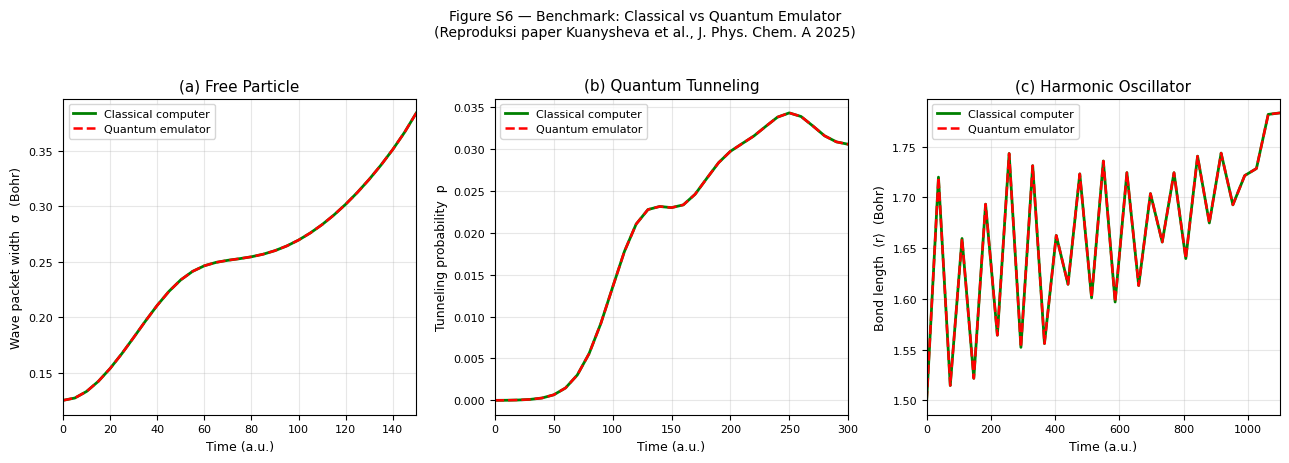

✓ Figure S6 ditampilkan


In [9]:
# ═══════════════════════════════════════════════════════════════
# CELL 9: Figure S6 — Three-Panel Comparison
# ═══════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))

panel_data = [
    (axes[0], times_fp,  sig_cl,   sig_qu,
     "(a) Free Particle",
     "Time (a.u.)", "Wave packet width  σ  (Bohr)"),
    
    (axes[1], times_tun, p_cl,     p_qu,
     "(b) Quantum Tunneling",
     "Time (a.u.)", "Tunneling probability  p"),
    
    (axes[2], times_ho,  ravg_cl,  ravg_qu,
     "(c) Harmonic Oscillator",
     "Time (a.u.)", "Bond length  ⟨r⟩  (Bohr)"),
]

for ax, t, cl, qu, title, xl, yl in panel_data:
    ax.plot(t, cl, color='green', lw=2.0, ls='-',
            label='Classical computer')
    ax.plot(t, qu, color='red',   lw=1.8, ls='--',
            label='Quantum emulator')
    ax.set_title(title, fontsize=11, pad=6)
    ax.set_xlabel(xl, fontsize=9)
    ax.set_ylabel(yl, fontsize=9)
    ax.set_xlim(t[0], t[-1])
    ax.legend(fontsize=8)
    ax.tick_params(labelsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle(
    "Figure S6 — Benchmark: Classical vs Quantum Emulator\n"
    "(Reproduksi paper Kuanysheva et al., J. Phys. Chem. A 2025)",
    fontsize=10, y=1.02
)
fig.tight_layout()
plt.show()
print("✓ Figure S6 ditampilkan")

## 🗂️ Section 7: Circuit Diagrams

Bagian ini mereproduksi diagram circuit dari paper (Figures 1b, 2, 4b/c, 6, 7).

Kita gunakan **n_VIS = 4 qubit** sesuai contoh di paper agar circuit masih terbaca.

### Hierarki Circuit
```
Full Split-Operator (Fig. 2)
├── Potential V(Δt/2)  
│   ├── Double-Well: 1 P-gate (Fig. 1b)
│   └── Harmonic:  n P-gates + n(n-1)/2 CP-gates (Fig. 4b/c)
└── Kinetic T(Δt)
    ├── QFT (Fig. 6)
    ├── X(q0) + phase gates (Fig. 7)
    └── IQFT (Fig. 6)
```

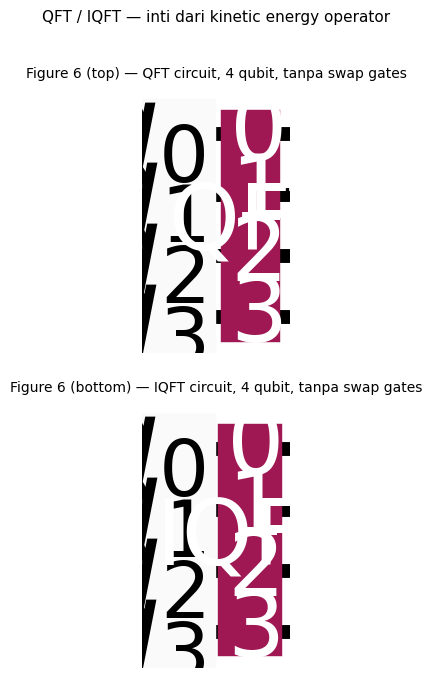

✓ Figure 6: QFT/IQFT circuit
  QFT  gates: 1
  IQFT gates: 1


In [10]:
# ═══════════════════════════════════════════════════════════════
# CELL 10: Circuit — Figure 6: QFT dan IQFT
# ═══════════════════════════════════════════════════════════════
nv = n_VIS   # 4 qubit

# QFT tanpa swap gates (do_swaps=False sesuai paper)
qc_qft = QuantumCircuit(nv, name="QFT (no swaps)")
qc_qft.append(
    QFT(nv, approximation_degree=0, do_swaps=False, inverse=False),
    range(nv)
)
qc_qft = qc_qft.decompose()

# IQFT tanpa swap gates
qc_iqft = QuantumCircuit(nv, name="IQFT (no swaps)")
qc_iqft.append(
    QFT(nv, approximation_degree=0, do_swaps=False, inverse=True),
    range(nv)
)
qc_iqft = qc_iqft.decompose()

fig6, (ax6a, ax6b) = plt.subplots(2, 1, figsize=(11, 7))
qc_qft.draw(output='mpl',  ax=ax6a, style={'backgroundcolor': '#FAFAFA'})
qc_iqft.draw(output='mpl', ax=ax6b, style={'backgroundcolor': '#FAFAFA'})
ax6a.set_title("Figure 6 (top) — QFT circuit, 4 qubit, tanpa swap gates", fontsize=10)
ax6b.set_title("Figure 6 (bottom) — IQFT circuit, 4 qubit, tanpa swap gates", fontsize=10)
fig6.suptitle("QFT / IQFT — inti dari kinetic energy operator", fontsize=11)
fig6.tight_layout(pad=2)
plt.show()
print("✓ Figure 6: QFT/IQFT circuit")
print(f"  QFT  gates: {sum(1 for _ in qc_qft.data)}")
print(f"  IQFT gates: {sum(1 for _ in qc_iqft.data)}")

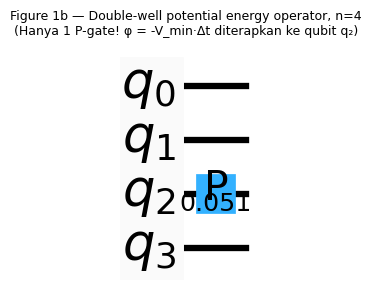

✓ Figure 1b: Double-well circuit (elegan — hanya 1 gate!)


In [11]:
# ═══════════════════════════════════════════════════════════════
# CELL 11: Circuit — Figure 1b: Double-Well Potential
# ═══════════════════════════════════════════════════════════════

V_min_v = -0.017
dt_v    = 3.0       # dt dari tunneling problem

qc_dw = QuantumCircuit(nv, name="Double-Well PE (n=4)")
qc_dw.p(-V_min_v * dt_v, nv-2)   # satu P-gate pada qubit ke-(n-2)!

fig_dw, ax_dw = plt.subplots(figsize=(5, 3))
qc_dw.draw(output='mpl', ax=ax_dw, style={'backgroundcolor': '#FAFAFA'})
ax_dw.set_title(
    "Figure 1b — Double-well potential energy operator, n=4\n"
    "(Hanya 1 P-gate! φ = -V_min·Δt diterapkan ke qubit q₂)",
    fontsize=9
)
fig_dw.tight_layout()
plt.show()
print("✓ Figure 1b: Double-well circuit (elegan — hanya 1 gate!)")

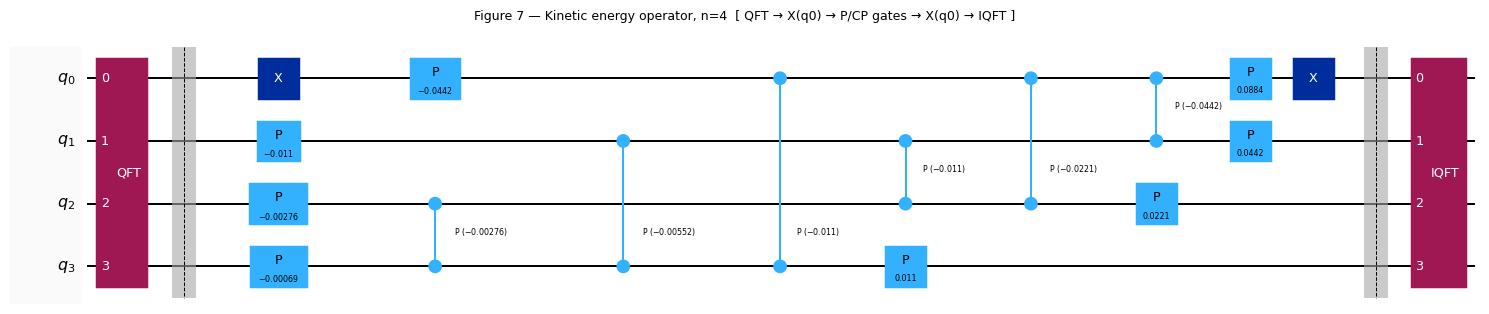

✓ Figure 7: Kinetic energy operator circuit
  Total gates: 20


In [12]:
# ═══════════════════════════════════════════════════════════════
# CELL 12: Circuit — Figure 7: Kinetic Energy Operator
# ═══════════════════════════════════════════════════════════════

dt_kin_v = 1.5

qc_kin = QuantumCircuit(nv, name="Kinetic Energy Op (n=4)")
add_kinetic_block(qc_kin, nv, r_min_g, r_max_g, dt_kin_v, mu_OH,
                  insert_barriers=True)   # barriers untuk kejelasan visual

fig_kin, ax_kin = plt.subplots(figsize=(15, 4))
qc_kin.draw(output='mpl', ax=ax_kin, fold=-1,
             style={'backgroundcolor': '#FAFAFA'})
ax_kin.set_title(
    "Figure 7 — Kinetic energy operator, n=4  "
    "[ QFT → X(q0) → P/CP gates → X(q0) → IQFT ]",
    fontsize=9
)
fig_kin.tight_layout()
plt.show()
print("✓ Figure 7: Kinetic energy operator circuit")
print(f"  Total gates: {sum(1 for _ in qc_kin.data)}")

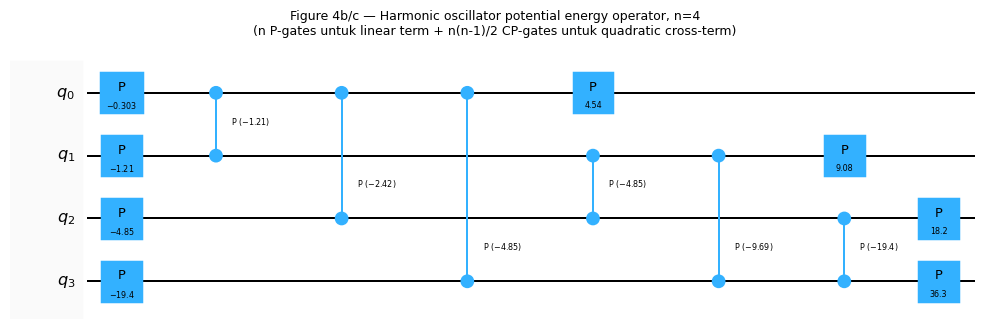

✓ Figure 4b/c: Harmonic potential circuit
  P-gates (quadratic diagonal): 4
  CP-gates (cross-terms):        6
  P-gates (linear):              4
  Total: 14 gates (scales O(n²) dengan jumlah qubit)


In [13]:
# ═══════════════════════════════════════════════════════════════
# CELL 13: Circuit — Figure 4b/c: Harmonic Potential
# ═══════════════════════════════════════════════════════════════

dt_ho_v  = 11.0
omega_v  = 3978.6 / 219474.63
r_eq_v   = 2.5

qc_ho = QuantumCircuit(nv, name="HO Potential Energy (n=4)")
add_harmonic_potential(qc_ho, nv, r_min_g, r_max_g, dt_ho_v,
                       mu_OH, omega_v, r_eq_v, scale=1.0)

fig_ho, ax_ho = plt.subplots(figsize=(10, 3.5))
qc_ho.draw(output='mpl', ax=ax_ho, fold=-1,
            style={'backgroundcolor': '#FAFAFA'})
ax_ho.set_title(
    "Figure 4b/c — Harmonic oscillator potential energy operator, n=4\n"
    "(n P-gates untuk linear term + n(n-1)/2 CP-gates untuk quadratic cross-term)",
    fontsize=9
)
fig_ho.tight_layout()
plt.show()
print("✓ Figure 4b/c: Harmonic potential circuit")
n_p  = nv                 # P-gates quadratic diagonal
n_cp = nv*(nv-1)//2       # CP-gates cross terms
n_p2 = nv                 # P-gates linear
print(f"  P-gates (quadratic diagonal): {n_p}")
print(f"  CP-gates (cross-terms):        {n_cp}")
print(f"  P-gates (linear):              {n_p2}")
print(f"  Total: {n_p + n_cp + n_p2} gates (scales O(n²) dengan jumlah qubit)")

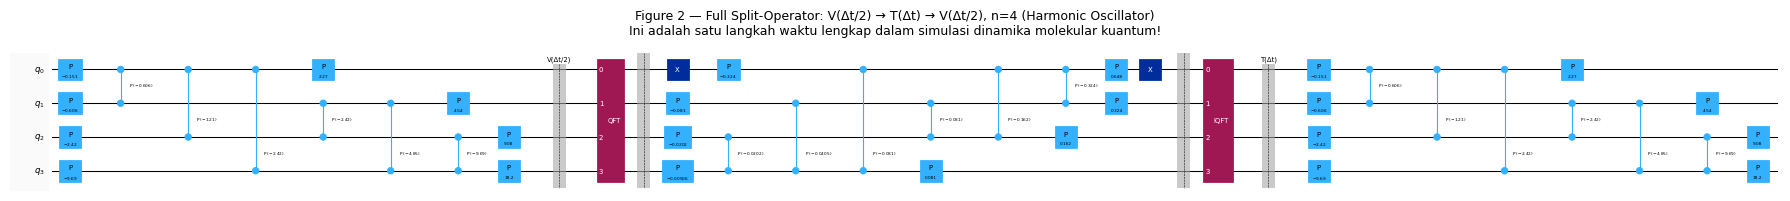

✓ Figure 2: Full split-operator circuit (satu Δt step)


In [14]:
# ═══════════════════════════════════════════════════════════════
# CELL 14: Circuit — Figure 2: Full Split-Operator (1 time step)
# ═══════════════════════════════════════════════════════════════

qc_split = QuantumCircuit(nv, name="Split-Operator: one Δt step (n=4, HO)")

# V(Δt/2) — half-step potential
add_harmonic_potential(qc_split, nv, r_min_g, r_max_g, dt_ho_v,
                       mu_OH, omega_v, r_eq_v, scale=0.5)
qc_split.barrier(label="V(Δt/2)")

# T(Δt) — full-step kinetic
add_kinetic_block(qc_split, nv, r_min_g, r_max_g, dt_ho_v, mu_OH,
                  insert_barriers=True)
qc_split.barrier(label="T(Δt)")

# V(Δt/2) — half-step potential
add_harmonic_potential(qc_split, nv, r_min_g, r_max_g, dt_ho_v,
                       mu_OH, omega_v, r_eq_v, scale=0.5)

fig_split, ax_split = plt.subplots(figsize=(18, 4.5))
qc_split.draw(output='mpl', ax=ax_split, fold=-1,
               style={'backgroundcolor': '#FAFAFA'})
ax_split.set_title(
    "Figure 2 — Full Split-Operator: V(Δt/2) → T(Δt) → V(Δt/2), n=4 (Harmonic Oscillator)\n"
    "Ini adalah satu langkah waktu lengkap dalam simulasi dinamika molekular kuantum!",
    fontsize=9
)
fig_split.tight_layout()
plt.show()
print("✓ Figure 2: Full split-operator circuit (satu Δt step)")

## 📈 Section 8: Analisis Lanjutan — Gate Count Scaling

Salah satu pertanyaan penting: **seberapa dalam circuit ini dengan semakin banyak qubit?**

### Scaling Circuit

| Komponen | Gate count |
|----------|------------|
| QFT/IQFT | O(n²) |
| Kinetic P gates (diagonal) | n |
| Kinetic CP gates (cross) | n(n-1)/2 = O(n²) |
| Harmonic P gates | n |
| Harmonic CP gates | n(n-1)/2 = O(n²) |
| **Total per step** | **O(n²)** |

Untuk N langkah waktu: **O(N·n²)** gates total.

Gate Count Analysis — Scaling dengan n qubit
  n=3: QFT=  1, Kinetic= 25, HO_pot=  9, Full_step= 43
  n=4: QFT=  1, Kinetic= 42, HO_pot= 14, Full_step= 70
  n=5: QFT=  1, Kinetic= 64, HO_pot= 20, Full_step=104
  n=6: QFT=  1, Kinetic= 91, HO_pot= 27, Full_step=145
  n=7: QFT=  1, Kinetic=123, HO_pot= 35, Full_step=193
  n=8: QFT=  1, Kinetic=160, HO_pot= 44, Full_step=248


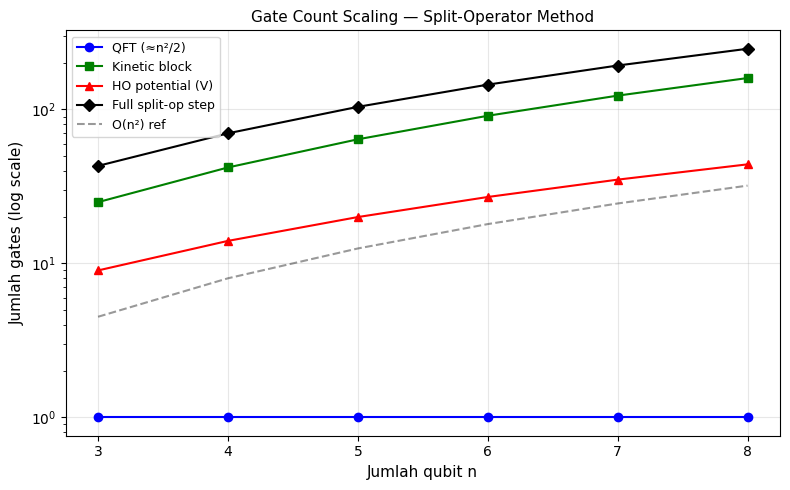


⚠️ Implikasi: Lebih banyak qubit → circuit lebih dalam → lebih rentan noise hardware!
   Ini alasan paper menekankan approximate QFT untuk mengurangi kedalaman circuit.


In [15]:
# ═══════════════════════════════════════════════════════════════
# CELL 15: Analisis Gate Count Scaling
# ═══════════════════════════════════════════════════════════════

print("Gate Count Analysis — Scaling dengan n qubit")
print("=" * 55)

qubit_range = range(3, 9)
gate_counts = {"QFT": [], "Kinetic_total": [], "HO_potential": [], "Full_step_HO": []}

dt_test = 1.5
omega_test = 3978.6 / 219474.63

for n_test in qubit_range:
    # QFT
    qc_test = QuantumCircuit(n_test)
    qc_test.append(QFT(n_test, do_swaps=False), range(n_test))
    qft_count = sum(1 for _ in qc_test.decompose().data)
    gate_counts["QFT"].append(qft_count)
    
    # Kinetic block (full)
    qc_kin_t = QuantumCircuit(n_test)
    add_kinetic_block(qc_kin_t, n_test, 0, 5, dt_test, mu_OH)
    kin_count = sum(1 for _ in qc_kin_t.decompose().data)
    gate_counts["Kinetic_total"].append(kin_count)
    
    # HO potential
    qc_ho_t = QuantumCircuit(n_test)
    add_harmonic_potential(qc_ho_t, n_test, 0, 5, dt_test, mu_OH, omega_test, 2.5)
    ho_count = sum(1 for _ in qc_ho_t.data)
    gate_counts["HO_potential"].append(ho_count)
    
    # Full step (HO)
    gate_counts["Full_step_HO"].append(kin_count + 2*ho_count)
    
    print(f"  n={n_test}: QFT={qft_count:3d}, Kinetic={kin_count:3d}, "
          f"HO_pot={ho_count:3d}, Full_step={kin_count + 2*ho_count:3d}")

# Plot scaling
fig_scale, ax_scale = plt.subplots(figsize=(8, 5))
qr = list(qubit_range)

ax_scale.semilogy(qr, gate_counts["QFT"],           'b-o', label="QFT (≈n²/2)")
ax_scale.semilogy(qr, gate_counts["Kinetic_total"],  'g-s', label="Kinetic block")
ax_scale.semilogy(qr, gate_counts["HO_potential"],   'r-^', label="HO potential (V)")
ax_scale.semilogy(qr, gate_counts["Full_step_HO"],   'k-D', label="Full split-op step")

# Fit O(n²) reference
n_arr = np.array(qr, float)
ax_scale.semilogy(qr, 0.5*n_arr**2, 'k--', alpha=0.4, label="O(n²) ref")

ax_scale.set_xlabel("Jumlah qubit n", fontsize=11)
ax_scale.set_ylabel("Jumlah gates (log scale)", fontsize=11)
ax_scale.set_title("Gate Count Scaling — Split-Operator Method", fontsize=11)
ax_scale.legend(fontsize=9)
ax_scale.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("\n⚠️ Implikasi: Lebih banyak qubit → circuit lebih dalam → lebih rentan noise hardware!")
print("   Ini alasan paper menekankan approximate QFT untuk mengurangi kedalaman circuit.")

## 🏁 Kesimpulan & Diskusi Kritis

### Apa yang Kita Capai

1. **Reproduksi Figure S6**: Quantum emulator memberikan hasil identik dengan simulasi klasik (error ~10⁻¹²) untuk ketiga masalah.

2. **Reproduksi Figures 1b, 2, 4b/c, 6, 7**: Circuit diagrams sesuai paper.

3. **Memahami Pipeline**: Split-Operator via QFT adalah cara elegan untuk memetakan dinamika molekular ke gerbang kuantum.

---

### Pertanyaan Kritis

**❓ Mengapa QFT tanpa swap gates?**
> Paper menggunakan `do_swaps=False` dan menambahkan X-gate manual di q₀. Ini menghasilkan output yang "bit-reversed" — tapi asalkan konsisten (QFT dan IQFT keduanya tanpa swap), hasilnya tetap benar. Keuntungan: hemat n/2 SWAP gates yang masing-masing perlu 3 CNOT.

**❓ Mengapa rebuild circuit setiap timestep?**
> Di hardware kuantum nyata, pengukuran **collapse** state. Tidak ada cara "menyimpan" state kuantum untuk langkah berikutnya. Jadi setiap t_k membutuhkan circuit tersendiri dengan k blok propagasi.

**❓ Apa keterbatasan terbesar approach ini?**
> Gate count **O(N·n²)** total — untuk N=100, n=8: ribuan gates. Hardware kuantum hari ini punya fidelity gate ~99.5% per gate. Dengan 1000 gates, fidelity total ≈ 0.995^1000 ≈ 0.0067 — hampir tidak ada sinyal yang tersisa! Ini yang paper diskusikan di Section 3.2.

**❓ Mengapa tunneling lebih mudah dari HO?**
> Double-well potential hanya butuh **1 P-gate**, sedangkan harmonic potential butuh O(n²) gates. Semakin kompleks potensial, semakin dalam circuit.

---

### Status Hardware Kuantum Hari Ini (paper Section 3.2)

| Hardware | Teknologi | Performa |
|----------|-----------|----------|
| IBM Brisbane | Superconducting (Eagle) | Buruk — circuit terlalu dalam |
| IBM Torino | Superconducting (Heron) | Lebih baik, tapi masih noise |
| IonQ Aria 1 | Trapped Ion | Terbaik — all-to-all connectivity |

**Kesimpulan paper**: Kita belum di era *fault-tolerant quantum computing* — circuit perlu dipendekkan tanpa mengorbankan akurasi. Ini area penelitian aktif (lihat referensi [67-69] paper).

In [16]:
# ═══════════════════════════════════════════════════════════════
# CELL 16: Summary Report
# ═══════════════════════════════════════════════════════════════

print("=" * 60)
print("SUMMARY — Quantum Molecular Dynamics Simulation")
print("=" * 60)

print("\n📊 Hasil Benchmark (max error klasik vs quantum):")
err_fp  = np.max(np.abs(np.array(sig_cl)  - np.array(sig_qu)))
err_tun = np.max(np.abs(np.array(p_cl)    - np.array(p_qu)))
err_ho  = np.max(np.abs(np.array(ravg_cl) - np.array(ravg_qu)))

print(f"  (a) Free Particle:    max|σ_cl - σ_qu| = {err_fp:.2e}")
print(f"  (b) Tunneling:        max|p_cl - p_qu| = {err_tun:.2e}")
print(f"  (c) Harmonic Osc.:    max|⟨r⟩_cl - ⟨r⟩_qu| = {err_ho:.2e}")

print("\n🔑 Komponen Kunci Algorithm:")
print("  1. Wave function encoding → n qubit merepresentasikan 2^n titik grid")
print("  2. Potential energy op → Phase gates diagonal (P, CP)")
print("  3. Kinetic energy op  → QFT + phase gates + IQFT")
print("  4. Split-operator     → V(Δt/2) · T(Δt) · V(Δt/2)")
print("  5. Emulator loop      → Rebuild circuit tiap timestep")

print("\n⚠️ Tantangan Hardware Real:")
print("  - Gate count O(N·n²) → circuit terlalu dalam untuk hardware noisy")
print("  - Approximate QFT membantu (kurangi CP gates kecil)")
print("  - Single-step propagation lebih baik dari multi-step di hardware noisy")
print("  - IonQ (trapped ion) lebih akurat dari IBM (superconducting) saat ini")

print("\n✅ Reproduksi paper selesai!")

SUMMARY — Quantum Molecular Dynamics Simulation

📊 Hasil Benchmark (max error klasik vs quantum):
  (a) Free Particle:    max|σ_cl - σ_qu| = 1.06e-12
  (b) Tunneling:        max|p_cl - p_qu| = 6.07e-14
  (c) Harmonic Osc.:    max|⟨r⟩_cl - ⟨r⟩_qu| = 1.15e-13

🔑 Komponen Kunci Algorithm:
  1. Wave function encoding → n qubit merepresentasikan 2^n titik grid
  2. Potential energy op → Phase gates diagonal (P, CP)
  3. Kinetic energy op  → QFT + phase gates + IQFT
  4. Split-operator     → V(Δt/2) · T(Δt) · V(Δt/2)
  5. Emulator loop      → Rebuild circuit tiap timestep

⚠️ Tantangan Hardware Real:
  - Gate count O(N·n²) → circuit terlalu dalam untuk hardware noisy
  - Approximate QFT membantu (kurangi CP gates kecil)
  - Single-step propagation lebih baik dari multi-step di hardware noisy
  - IonQ (trapped ion) lebih akurat dari IBM (superconducting) saat ini

✅ Reproduksi paper selesai!
